# 🩺 Tuberculosis Detection from Chest X-Rays
A deep learning model using DenseNet121 transfer learning to detect
tuberculosis from chest X-ray images.

## Dataset
Download from Kaggle:
https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset

After downloading, extract and place:

data/TB_Chest_Radiography_Database/Tuberculosis/
data/TB_Chest_Radiography_Database/Normal/

In [1]:
#INSTALLING AND IMPORTING NECESSARY PACKAGES AND LIBRARIES

#INSTALLING NECESSARY PACKAGES
!pip install -q tensorflow==2.19.0
!pip install -q scikit-plot

#IMPORTING LIBRARIES
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import itertools
from glob import glob
import cv2
from tqdm import tqdm
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

In [ ]:
#SETTING  RANDOM SEEDS FOR REPRODUCIBILITY

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
#SETTING DATASET PATH
# Download dataset from Kaggle and place in data/ folder
# https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset

data_dir = "data/TB_Chest_Radiography_Database"

# Verify dataset exists
if os.path.exists(data_dir):
    print("Dataset found!")
    print("Folders:", os.listdir(data_dir))
else:
    print("Dataset not found. Please download from Kaggle and place in data/ folder")

In [ ]:
#Listing the  class folders and counts

for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, "->", len(os.listdir(cls_path)))

TB_Chest_Radiography_Database -> 5


In [ ]:
# Manually specify the actual image folders

classes = ["Tuberculosis", "Normal"]

**EXPLORATORY DATA ANALYSIS**

In [ ]:
#Basic Image EDA

#COUNTING IMAGES PER CLASS
counts = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    # Only count image files
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    counts[cls] = len(files)

print("Classes:", classes)
print("Image count per class:", counts)

Classes: ['Tuberculosis', 'Normal']
Image count per class: {'Tuberculosis': 700, 'Normal': 3500}


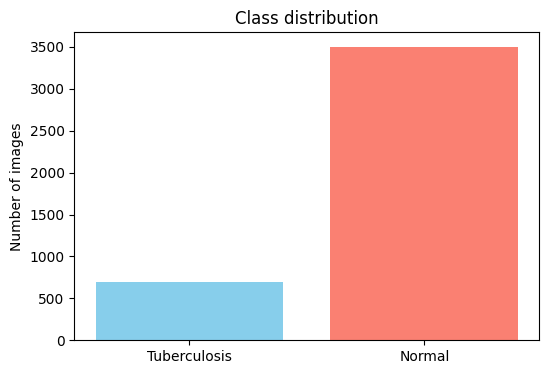

In [ ]:
# Display class imbalance bar chart
plt.figure(figsize=(6,4))
plt.bar(classes, [counts[c] for c in classes], color=['skyblue','salmon'])
plt.title("Class distribution")
plt.ylabel("Number of images")
plt.show()

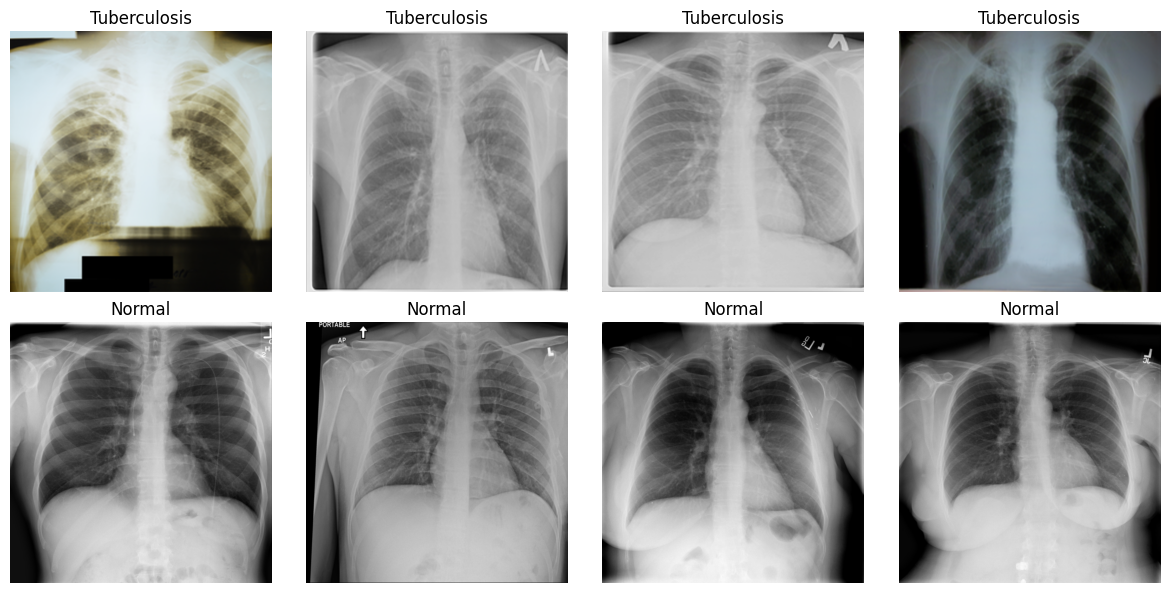

In [ ]:
#VISUALIZING SAMPLE IMAGES

from PIL import Image

# Displaying sample images from each class
def show_sample_images(data_dir, classes, n=4):
    plt.figure(figsize=(12, len(classes)*3))
    i = 1
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        # Filter to include only common image file extensions
        imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if not imgs:  # Handle cases where no image files are found
            print(f"No image files found for class: {cls}")
            continue
        sample = random.sample(imgs, min(n, len(imgs)))
        for s in sample:
            img = Image.open(s)
            plt.subplot(len(classes), n, i)
            plt.imshow(img, cmap='gray')
            plt.title(f"{cls}")
            plt.axis('off')
            i += 1
    plt.tight_layout()
    plt.show()

# Show sample images
show_sample_images(data_dir, classes, n=4)

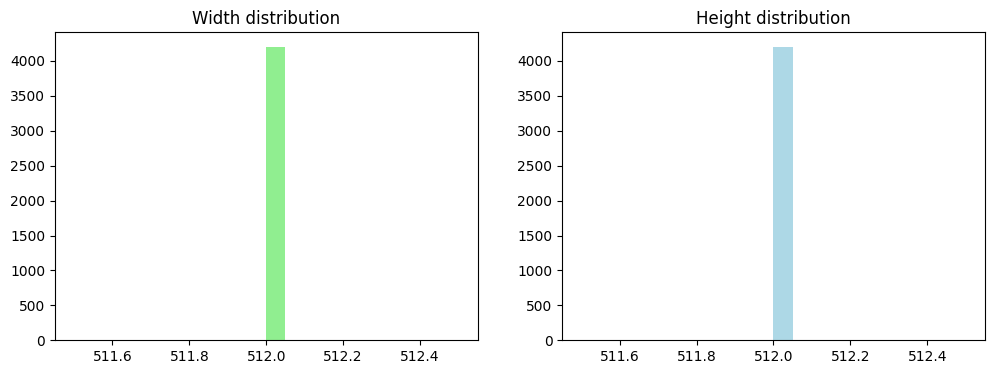

In [ ]:
#Checking image sizes OR shapes distribution

sizes = []
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for f in os.listdir(cls_path):
        try:
            img = Image.open(os.path.join(cls_path, f))
            sizes.append(img.size)  # (width, height)
        except:
            pass

widths, heights = zip(*sizes)

# Plotting Size Distribution

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='lightgreen')
plt.title("Width distribution")
plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='lightblue')
plt.title("Height distribution")
plt.show()

In [ ]:
#Checking Corrupted Images
corrupt_images = []
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for f in os.listdir(cls_path):
        try:
            img = Image.open(os.path.join(cls_path,f))
            img.verify()
        except:
            corrupt_images.append(os.path.join(cls_path,f))

print("Corrupt images:", corrupt_images if corrupt_images else "None found")


Corrupt images: None found


In [ ]:
#PIXEL INTENSITY STATISTICS
# Checking pixel intensity or the  grayscale value statistics for a few samples
def pixel_stats(path, num=5):
    imgs = random.sample(glob(path + "/*"), num)
    for p in imgs:
        im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        print(p, "-- min:", im.min(), "max:", im.max(), "mean:", im.mean(), "std:", im.std())

for cls in classes:
    print("Stats for class:", cls)
    pixel_stats(os.path.join(data_dir, cls), num=3)


Stats for class: Tuberculosis
/content/tuberculosis_dataset/TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-155.png -- min: 0 max: 247 mean: 114.65913009643555 std: 43.26222805357777
/content/tuberculosis_dataset/TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-401.png -- min: 0 max: 255 mean: 113.88232803344727 std: 69.75466458088962
/content/tuberculosis_dataset/TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-563.png -- min: 0 max: 199 mean: 108.65423965454102 std: 43.91528642743853
Stats for class: Normal
/content/tuberculosis_dataset/TB_Chest_Radiography_Database/Normal/Normal-3342.png -- min: 0 max: 255 mean: 119.64976119995117 std: 65.32131353970331
/content/tuberculosis_dataset/TB_Chest_Radiography_Database/Normal/Normal-1626.png -- min: 0 max: 235 mean: 163.26561737060547 std: 50.04592804335859
/content/tuberculosis_dataset/TB_Chest_Radiography_Database/Normal/Normal-83.png -- min: 0 max: 255 mean: 130.91135025024414 std: 68.3615801225941


**IMAGE ENHANCEMENT**

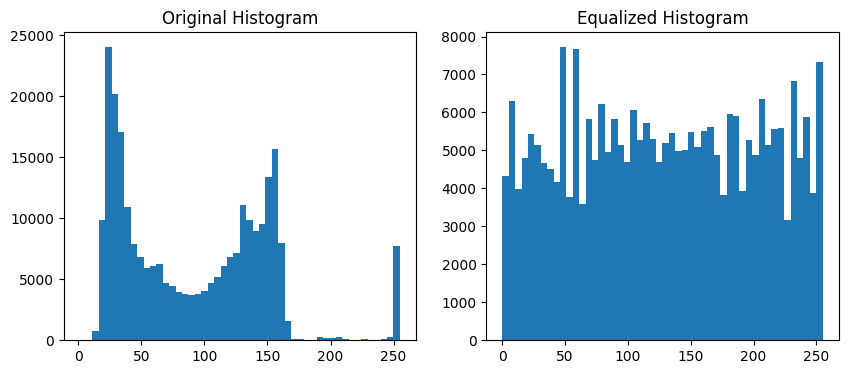

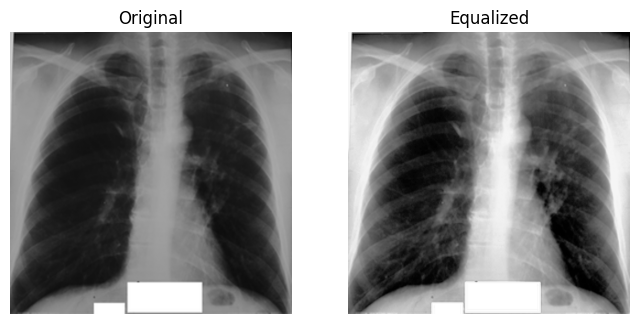

In [ ]:
#Histogram & Histogram Equalization

def enhance_and_show(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    equ = cv2.equalizeHist(img)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(img.ravel(), bins=50)
    plt.title("Original Histogram")
    plt.subplot(1,2,2)
    plt.hist(equ.ravel(), bins=50)
    plt.title("Equalized Histogram")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(equ, cmap='gray')
    plt.title("Equalized")
    plt.axis('off')
    plt.show()

# Testing on one sample
sample_img = os.path.join(data_dir, classes[0], os.listdir(os.path.join(data_dir,classes[0]))[0])
enhance_and_show(sample_img)


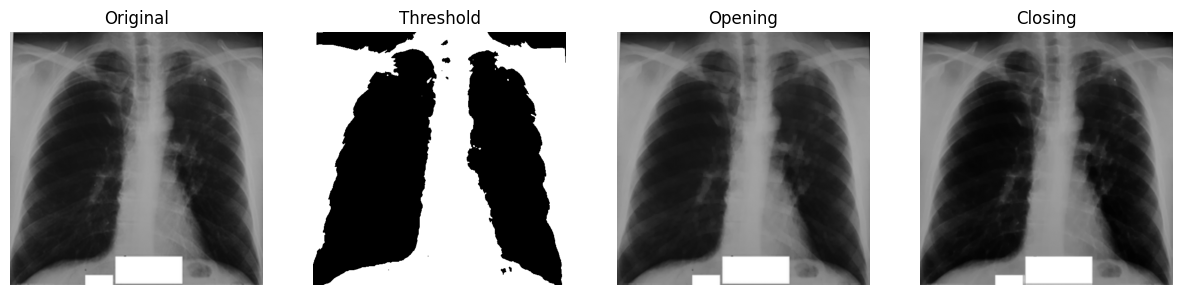

In [ ]:
#Thresholding and Morphological Operations (Such as OPENING and CLOSING)

def morph_ops(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    kernel = np.ones((5,5),np.uint8)
    opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    titles = ['Original','Threshold','Opening','Closing']
    imgs = [img, thresh, opening, closing]

    plt.figure(figsize=(15,4))
    for i, im in enumerate(imgs):
        plt.subplot(1,4,i+1)
        plt.imshow(im, cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

morph_ops(sample_img)


In [ ]:
#Text Exploratory Data Analysis

# Filenames analysis
all_files = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir) for f in filenames]
file_lengths = [len(os.path.basename(f)) for f in all_files]
print("Filename length stats: min={}, max={}, mean={:.2f}".format(min(file_lengths), max(file_lengths), np.mean(file_lengths)))

# Class name frequency from folder names
print("Class counts from folder names:", counts)


Filename length stats: min=12, max=26, mean=15.55
Class counts from folder names: {'Tuberculosis': 700, 'Normal': 3500}


**PREPROCESSING**

In [ ]:
#SPLITTING AND TRAINING THE DATA


# Defining the split ratios for train, validation, and test datasets
split_ratio_train = 0.7     # 70% for training
split_ratio_val = 0.15       # 15% for validation (remaining 15% will be test)

# Define base directories for the dataset splits
base = 'data/tb_splits'
train_dir = os.path.join(base, 'train')
val_dir   = os.path.join(base, 'val')
test_dir  = os.path.join(base, 'test')

# Create the directories if they do not exist
for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# List of class names
class_names = classes

# Loop over each class to split and copy images into train/val/test folders
for cls in class_names:
    src = os.path.join(data_dir, cls)
    files = sorted(glob(os.path.join(src, '*')))

    # Split images into train (70%) and temporary set (30%)
    train_files, temp = train_test_split(files, train_size=split_ratio_train, random_state=SEED)

    # Split temporary set equally into validation (15%) and test (15%)
    val_files, test_files = train_test_split(temp, test_size=0.5, random_state=SEED)

    # Copy files into their respective directories
    for d, f_list in zip([train_dir, val_dir, test_dir], [train_files, val_files, test_files]):
        cls_d = os.path.join(d, cls)
        os.makedirs(cls_d, exist_ok=True)
        for f in f_list:
            shutil.copy(f, os.path.join(cls_d, os.path.basename(f)))

#Print number of images per class in each split
for split in ['train','val','test']:
    p = os.path.join(base, split)
    print(split, {cls: len(os.listdir(os.path.join(p, cls))) for cls in class_names})


train {'Tuberculosis': 489, 'Normal': 2450}
val {'Tuberculosis': 105, 'Normal': 525}
test {'Tuberculosis': 106, 'Normal': 525}


In [ ]:
#PREPROCESING & AUGMENTATION

# Define target image size and batch size for training
IMG_SIZE = (224,224)
BATCH_SIZE = 16

# Training data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=densenet_preprocess,  # DenseNet preprocessing
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test data
val_test_datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess)

# Creating generators for train, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=True, seed=SEED
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)


Found 2939 images belonging to 2 classes.
Found 630 images belonging to 2 classes.
Found 631 images belonging to 2 classes.


In [ ]:
#HANDLING CLASS IMBALANCE

# Training counts
train_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names]
print("Train counts per class:", dict(zip(class_names, train_counts)))

# Create y_train labels
y_train = np.concatenate([[i]*count for i, count in enumerate(train_counts)])
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)


Train counts per class: {'Tuberculosis': 489, 'Normal': 2450}
Class weights: {0: np.float64(3.005112474437628), 1: np.float64(0.5997959183673469)}


**MODELING**

In [ ]:
#ARCHITECTURE DESIGN (DenseNet121 transfer learning)

# Loading DenseNet121 pretrained on ImageNet
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # Freeze base model to retain pretrained features

# Building a custom classifier on top
inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)                 # Reduce overfitting
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

# Creating and compiling the model
model = models.Model(inputs, outputs)
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]  # Accuracy and AUC
)

# Show model architecture
model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

In [ ]:
#Training strategy (head first)

EPOCHS_HEAD = 5
checkpoint_cb = callbacks.ModelCheckpoint('best_model_head.keras', save_best_only=True, monitor='val_auc', mode='max', verbose=1)
earlystop_cb = callbacks.EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True)
reduce_lr_cb = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-7, mode='max')

history_head = model.fit(
    train_generator,
    epochs=EPOCHS_HEAD,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)


Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.7530 - auc: 0.9101 - loss: 1.4650
Epoch 1: val_auc improved from -inf to 0.96878, saving model to best_model_head.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 91s 490ms/step - accuracy: 0.7531 - auc: 0.9101 - loss: 1.4642 - val_accuracy: 0.9730 - val_auc: 0.9688 - val_loss: 0.1696 - learning_rate: 1.0000e-04
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8077 - auc: 0.9280 - loss: 1.1678
Epoch 2: val_auc improved from 0.96878 to 0.97800, saving model to best_model_head.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 339ms/step - accuracy: 0.8079 - auc: 0.9280 - loss: 1.1672 - val_accuracy: 0.9746 - val_auc: 0.9780 - val_loss: 0.1314 - learning_rate: 1.0000e-04
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8648 - auc: 0.9458 - loss: 0.9188
Epoch 3: val_auc improved from 0.97800 to 0.98121, saving model to best_model_head.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 338ms/step - accuracy: 0.8648 - auc: 0.9458 - loss: 0.9182 - val_accuracy: 0.9667 - val_auc: 0.9812 - val_loss: 0.1079 - learning_rate: 1.0000e-04
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.8858 - auc: 0.9440 - loss: 0.7720
Epoch 4: val_auc improved from 0.98121 to 0.98477, saving model to best_model_head.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 338ms/step - accuracy: 0.8858 - auc: 0.9440 - loss: 0.7719 - val_accuracy: 0.9714 - val_auc: 0.9848 - val_loss: 0.0984 - learning_rate: 1.0000e-04
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8947 - auc: 0.9413 - loss: 0.6337
Epoch 5: val_auc improved from 0.98477 to 0.98771, saving model to best_model_head.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 339ms/step - accuracy: 0.8947 - auc: 0.9413 - loss: 0.6336 - val_accuracy: 0.9683 - val_auc: 0.9877 - val_loss: 0.0974 - learning_rate: 1.0000e-04


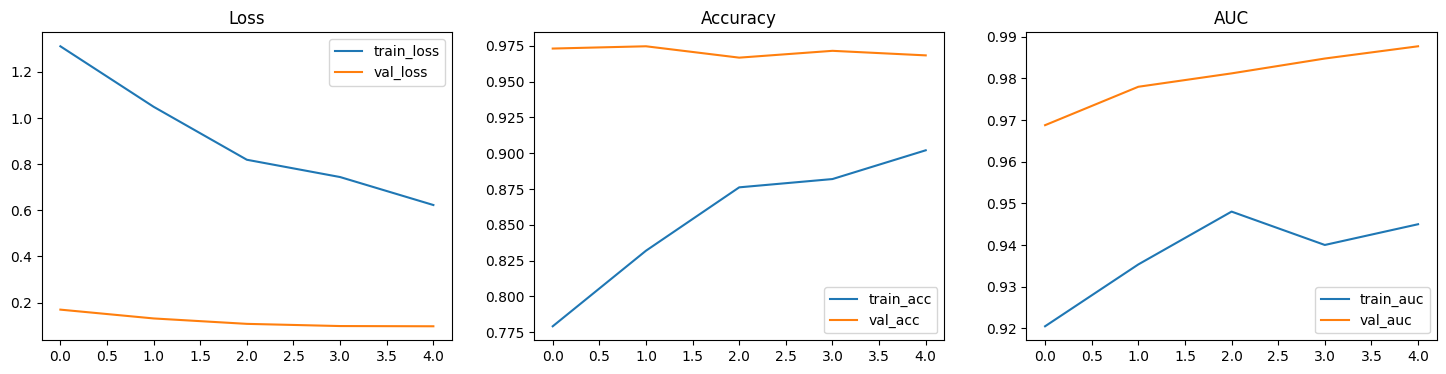

In [ ]:
#Plot training curves (loss, accuracy, AUC)

def plot_history(h):
    # Plot training and validation loss, accuracy, and AUC
    fig, axes = plt.subplots(1, 3, figsize=(18,4))

    # Loss
    axes[0].plot(h.history['loss'], label='train_loss')
    axes[0].plot(h.history['val_loss'], label='val_loss')
    axes[0].legend()
    axes[0].set_title('Loss')

    # Accuracy
    axes[1].plot(h.history['accuracy'], label='train_acc')
    axes[1].plot(h.history['val_accuracy'], label='val_acc')
    axes[1].legend()
    axes[1].set_title('Accuracy')

    # AUC
    if 'auc' in h.history:
        axes[2].plot(h.history['auc'], label='train_auc')
        axes[2].plot(h.history['val_auc'], label='val_auc')
        axes[2].legend()
        axes[2].set_title('AUC')

    plt.show()

# Call the function
plot_history(history_head)


In [ ]:
#Evaluation on test set


# Loading the best head-only model
model.load_weights('best_model_head.keras')

# Predict on test set
test_steps = test_generator.samples // test_generator.batch_size + int(test_generator.samples % test_generator.batch_size != 0)
pred_probs = model.predict(test_generator, steps=test_steps, verbose=1)
preds = (pred_probs.ravel() >= 0.5).astype(int)

# True labels
y_true = test_generator.classes[:len(preds)]

# Confusion matrix & classification report
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

cm = confusion_matrix(y_true, preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_true, preds, target_names=class_names))

# Manual metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average='binary')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 537ms/step
Confusion matrix:
 [[524   1]
 [ 18  88]]

Classification report:
               precision    recall  f1-score   support

Tuberculosis       0.97      1.00      0.98       525
      Normal       0.99      0.83      0.90       106

    accuracy                           0.97       631
   macro avg       0.98      0.91      0.94       631
weighted avg       0.97      0.97      0.97       631

Precision: 0.9888, Recall: 0.8302, F1: 0.9026


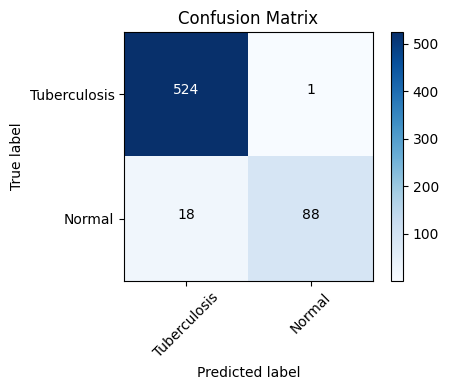

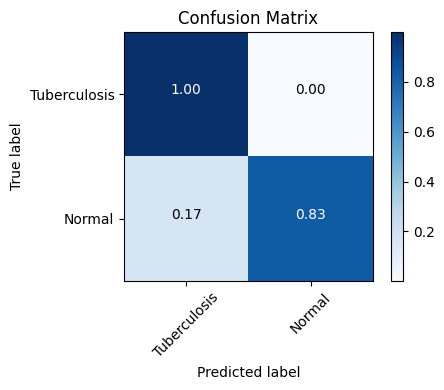

In [ ]:
#Confusion matrix plots

def plot_confusion_matrix(cm, classes, normalize=False):
    plt.figure(figsize=(5,4))
    mat = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] if normalize else cm
    plt.imshow(mat, cmap=plt.cm.Blues)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = mat.max()/2.
    for i,j in itertools.product(range(mat.shape[0]), range(mat.shape[1])):
        plt.text(j,i,format(mat[i,j],fmt),ha='center',color='white' if mat[i,j]>thresh else 'black')
    plt.ylabel('True label'); plt.xlabel('Predicted label'); plt.title('Confusion Matrix')
    plt.tight_layout(); plt.show()

plot_confusion_matrix(cm, class_names, normalize=False)
plot_confusion_matrix(cm, class_names, normalize=True)


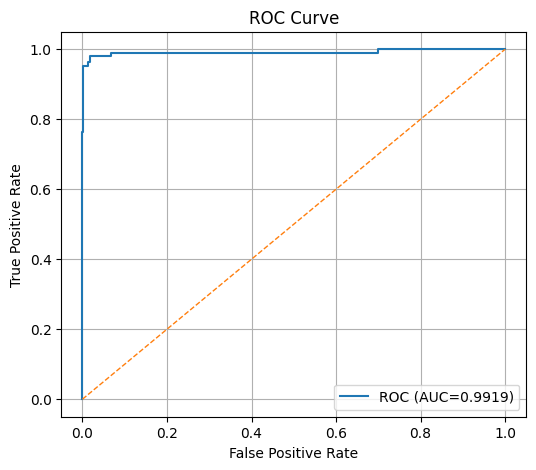

In [ ]:
#ROC Curve & AUC

fpr, tpr, _ = roc_curve(y_true, pred_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})')
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


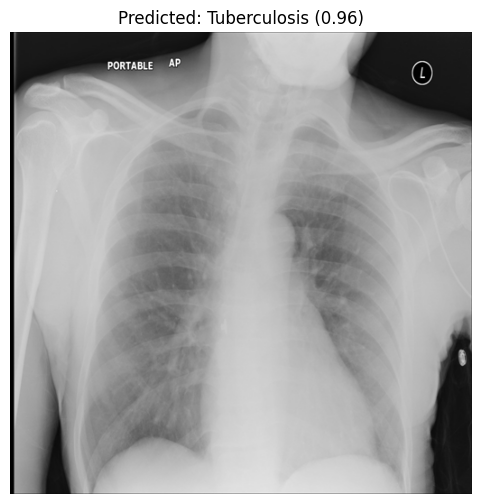

In [ ]:
# Prediction Visualization

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model

#Making prediction
preds = model.predict(img_array)
pred_class = class_names[np.argmax(preds)]
pred_prob = np.max(preds)

# Displaying the  original image with prediction
plt.figure(figsize=(6,6))
plt.imshow(orig_rgb)
plt.title(f"Predicted: {pred_class} ({pred_prob:.2f})")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


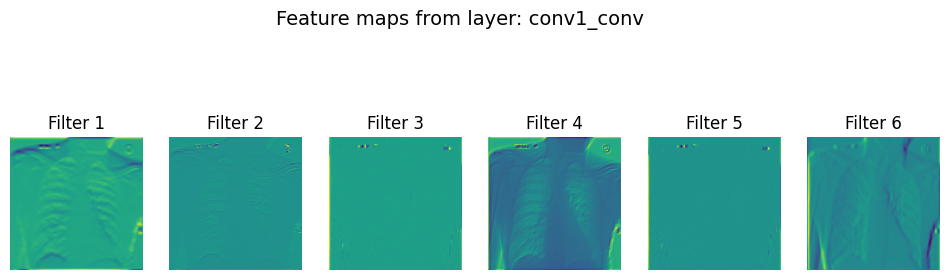

In [ ]:
#Feature Map Visualization
# Use the base_model (DenseNet121)

# Automatically pick the first Conv2D layer
first_conv_name = None
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_name = layer.name
        break

if first_conv_name is None:
    raise ValueError("No Conv2D layer found in base_model.")

# Build intermediate model to get activations
activation_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(first_conv_name).output
)

# Getting activations
activations = activation_model.predict(img_array)

# Displaying first 6 feature maps
plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(activations[0,:,:,i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.suptitle(f'Feature maps from layer: {first_conv_name}', fontsize=14)
plt.show()